# Course Project N.03: Clinical Records
**authors:** Vojtěch Tichý, Sávio Campos de Souza <br>
https://www.overleaf.com/3315726454qptfqhmwhcpy#04e0ee

In [175]:
%pip install -q numpy pandas matplotlib seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Note: you may need to restart the kernel to use updated packages.


In [176]:
df = pd.read_csv('03_ClinicalRecords_Clustering/20_Clinical Records/diabetic_data.csv')
ids_df = pd.read_csv('03_ClinicalRecords_Clustering/20_Clinical Records/IDs_mapping.csv')

df

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [177]:
ids_df

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
...,...,...
62,22,Transfer from hospital inpt/same fac reslt in...
63,23,Born inside this hospital
64,24,Born outside this hospital
65,25,Transfer from Ambulatory Surgery Center


First, we process the dataframes with mappings and combine them with dataset.

In [201]:
admission_type_id_mapping = ids_df.loc[0:8]
discharge_disposition_id_mapping = ids_df.loc[10:40]
admission_source_id_mapping = ids_df.loc[42:]
admission_type_id_mapping, discharge_disposition_id_mapping, admission_source_id_mapping

(  admission_type_id    description
 0                 1      Emergency
 1                 2         Urgent
 2                 3       Elective
 3                 4        Newborn
 4                 5  Not Available
 5                 6            NaN
 6                 7  Trauma Center
 7                 8     Not Mapped
 8               NaN            NaN,
    admission_type_id                                        description
 10                 1                                 Discharged to home
 11                 2  Discharged/transferred to another short term h...
 12                 3                      Discharged/transferred to SNF
 13                 4                      Discharged/transferred to ICF
 14                 5  Discharged/transferred to another type of inpa...
 15                 6  Discharged/transferred to home with home healt...
 16                 7                                           Left AMA
 17                 8  Discharged/transferred to home u

In [ ]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


## Exploratory analysis
First we look at the categorical attributes.

In [ ]:

def plot_numerical_cols(df: pd.DataFrame, col_cnt: int = 4) -> None:
	"""
	@brief plots distributions of all numerical attributes

	@param df input dataframe
	@param col_cnt number of plot columns
	"""
	
	numerical_cols = df.select_dtypes(include=['int', 'float']).columns
	fig, axes = plt.subplots(len(numerical_cols) // 4 + 1, col_cnt, figsize=(12,20))
	axes = axes.flatten()

	for i, col in enumerate(numerical_cols):
		sns.violinplot(data=df, y=col, ax=axes[i])
		axes[i].set_ylabel("")
		axes[i].set_xlabel(col, fontsize=16)
	
	# to hide excess subplot axes 
	for i in range(len(numerical_cols), len(axes)):
		axes[i].set_visible(False)

	plt.suptitle('Violin plots of numerical attributes', fontsize=24, y=1)
	plt.tight_layout()
	plt.show()


def plot_categorical_cols(df: pd.DataFrame, col_cnt: int = 4) -> None:
	"""
	@brief plots a grid of countplots of all categorical attributes

	@param df input dataframe
	@param col_cnt number of plot columns
	"""
	
	categorical_cols = df.select_dtypes(include=['str', 'category']).columns
	fig, axes = plt.subplots(len(categorical_cols) // 4 + 1, col_cnt, figsize=(16,20))
	axes = axes.flatten()

	for i, col in enumerate(categorical_cols):
		sns.countplot(data=df, x=col, ax=axes[i])
		axes[i].set_ylabel("")
		axes[i].set_xlabel(col, fontsize=16)
	
	# to hide excess subplot axes 
	for i in range(len(categorical_cols), len(axes)):
		axes[i].set_visible(False)

	fig.supylabel('Count', fontsize=20)
	plt.suptitle('Coutplots of categorical attributes', fontsize=24, y=1)
	plt.tight_layout()
	plt.show()


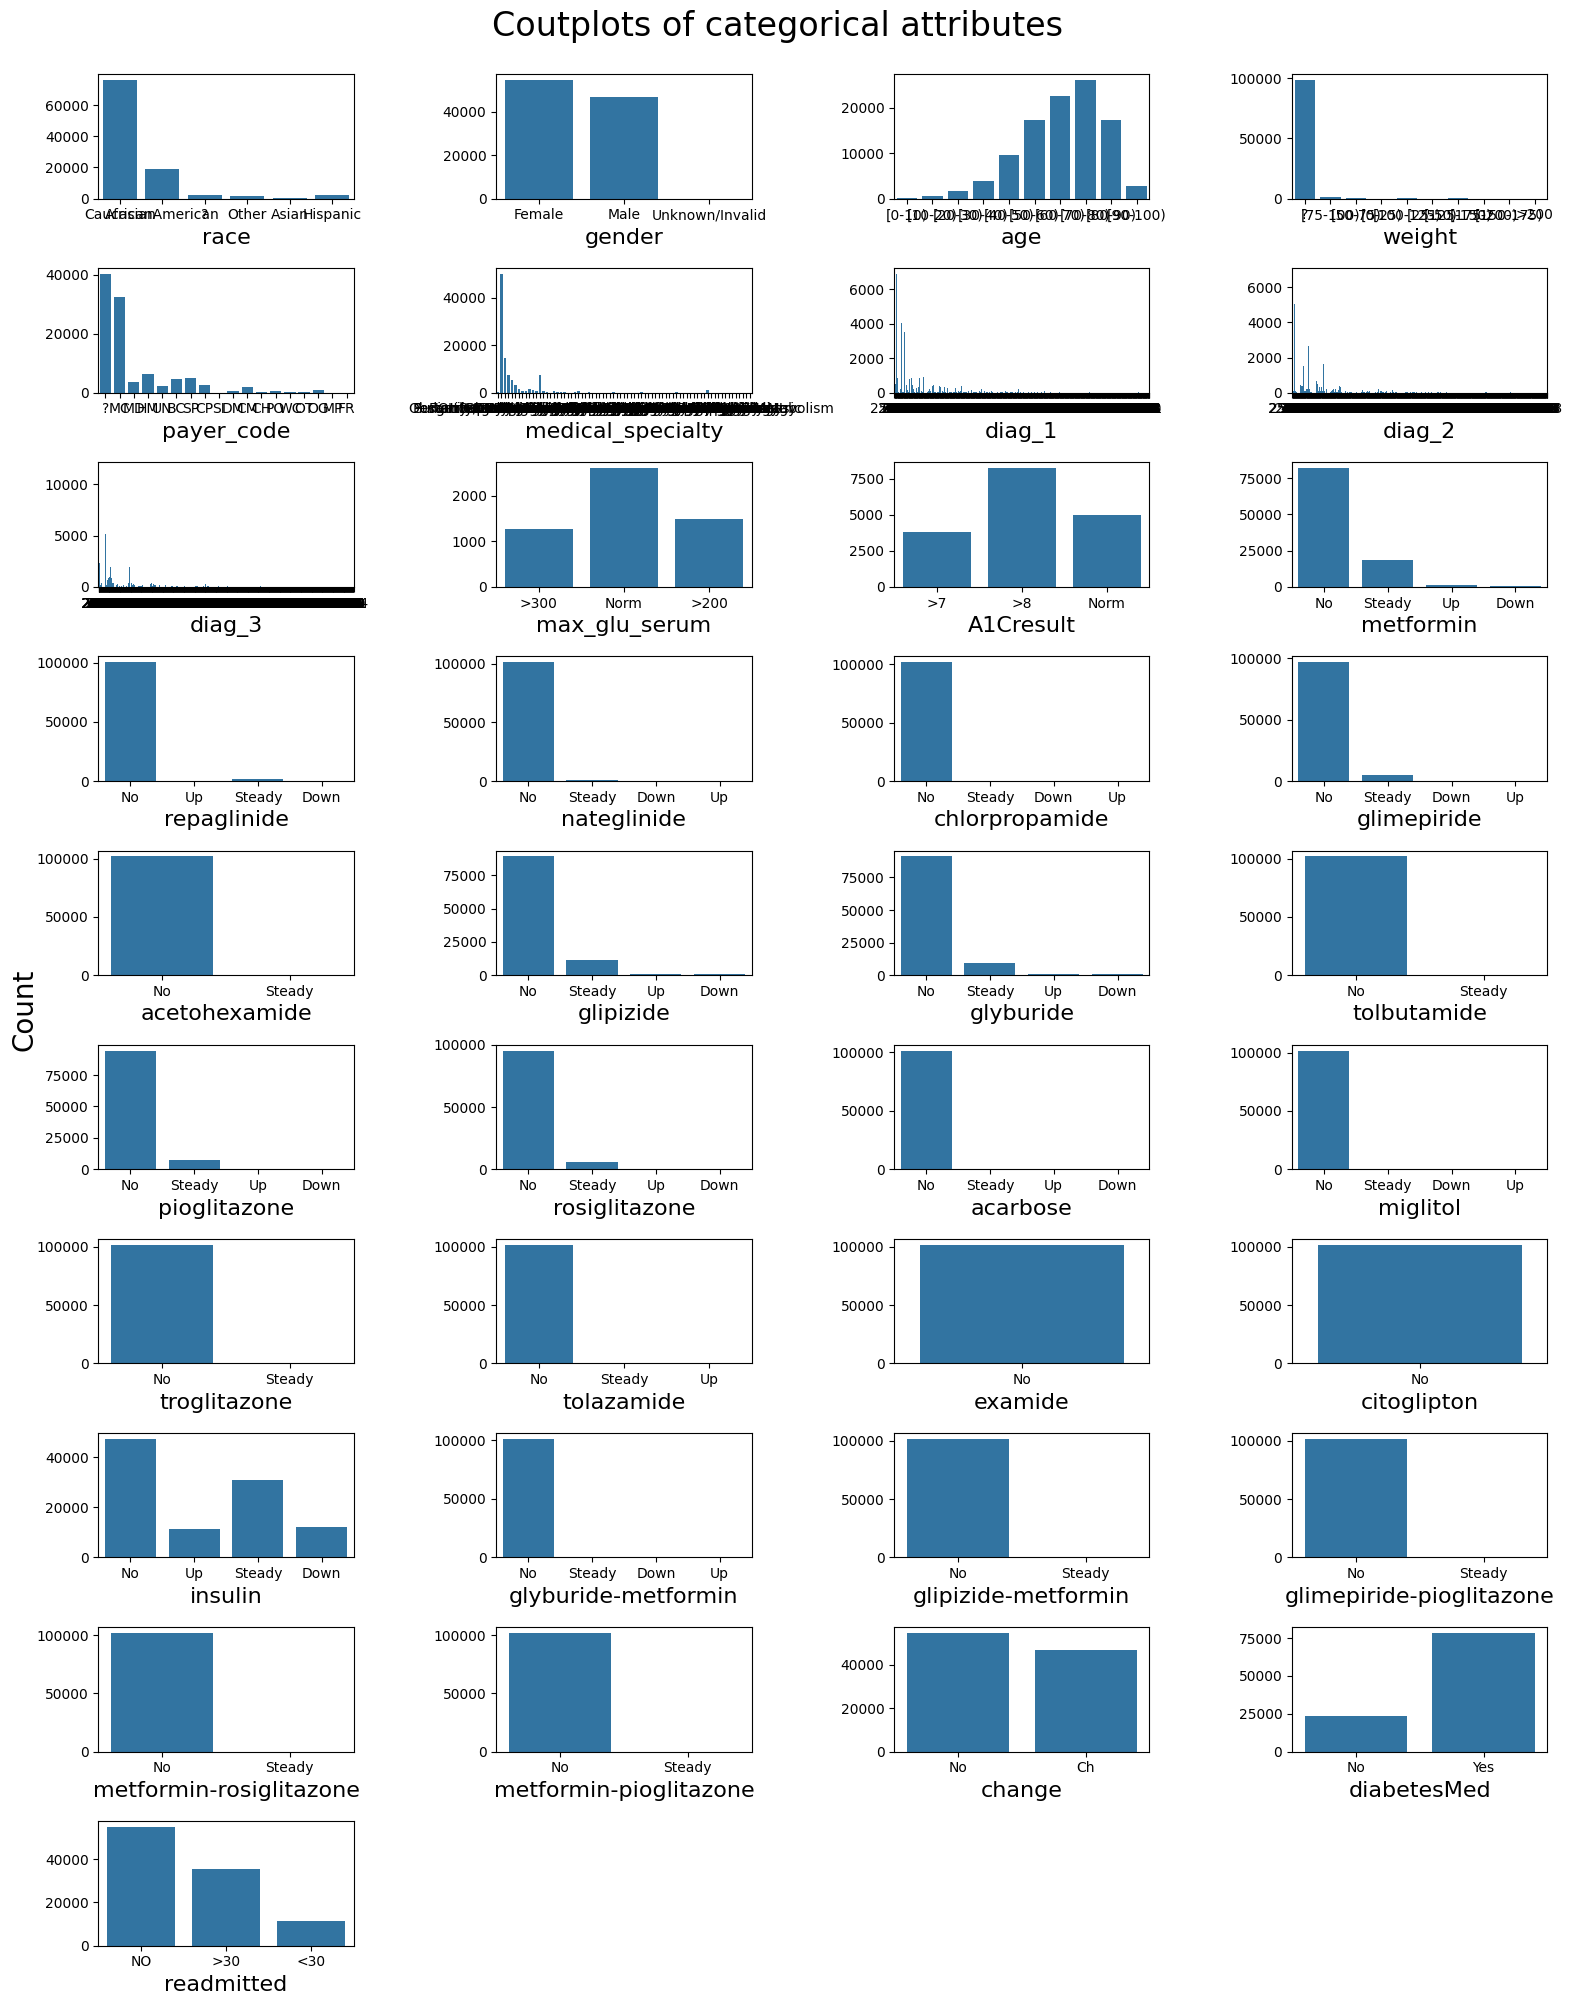

In [ ]:
plot_categorical_cols(df)


From the graphs we can clearly see attributes, which have one values in all rows. We can drop thsese columns, since they do not bring any value. There are also a lot of columns which have one value in over 90% of its rows.

In [ ]:
columns_to_drop = []

for col in df.columns:
    if len(df[col].unique()) <= 1:
        columns_to_drop.append(col)

df.drop(columns=columns_to_drop, inplace=True)
print(f"{len(columns_to_drop)} columns are dropped: {columns_to_drop}")

2 columns are dropped: ['examide', 'citoglipton']


### Numerical columns

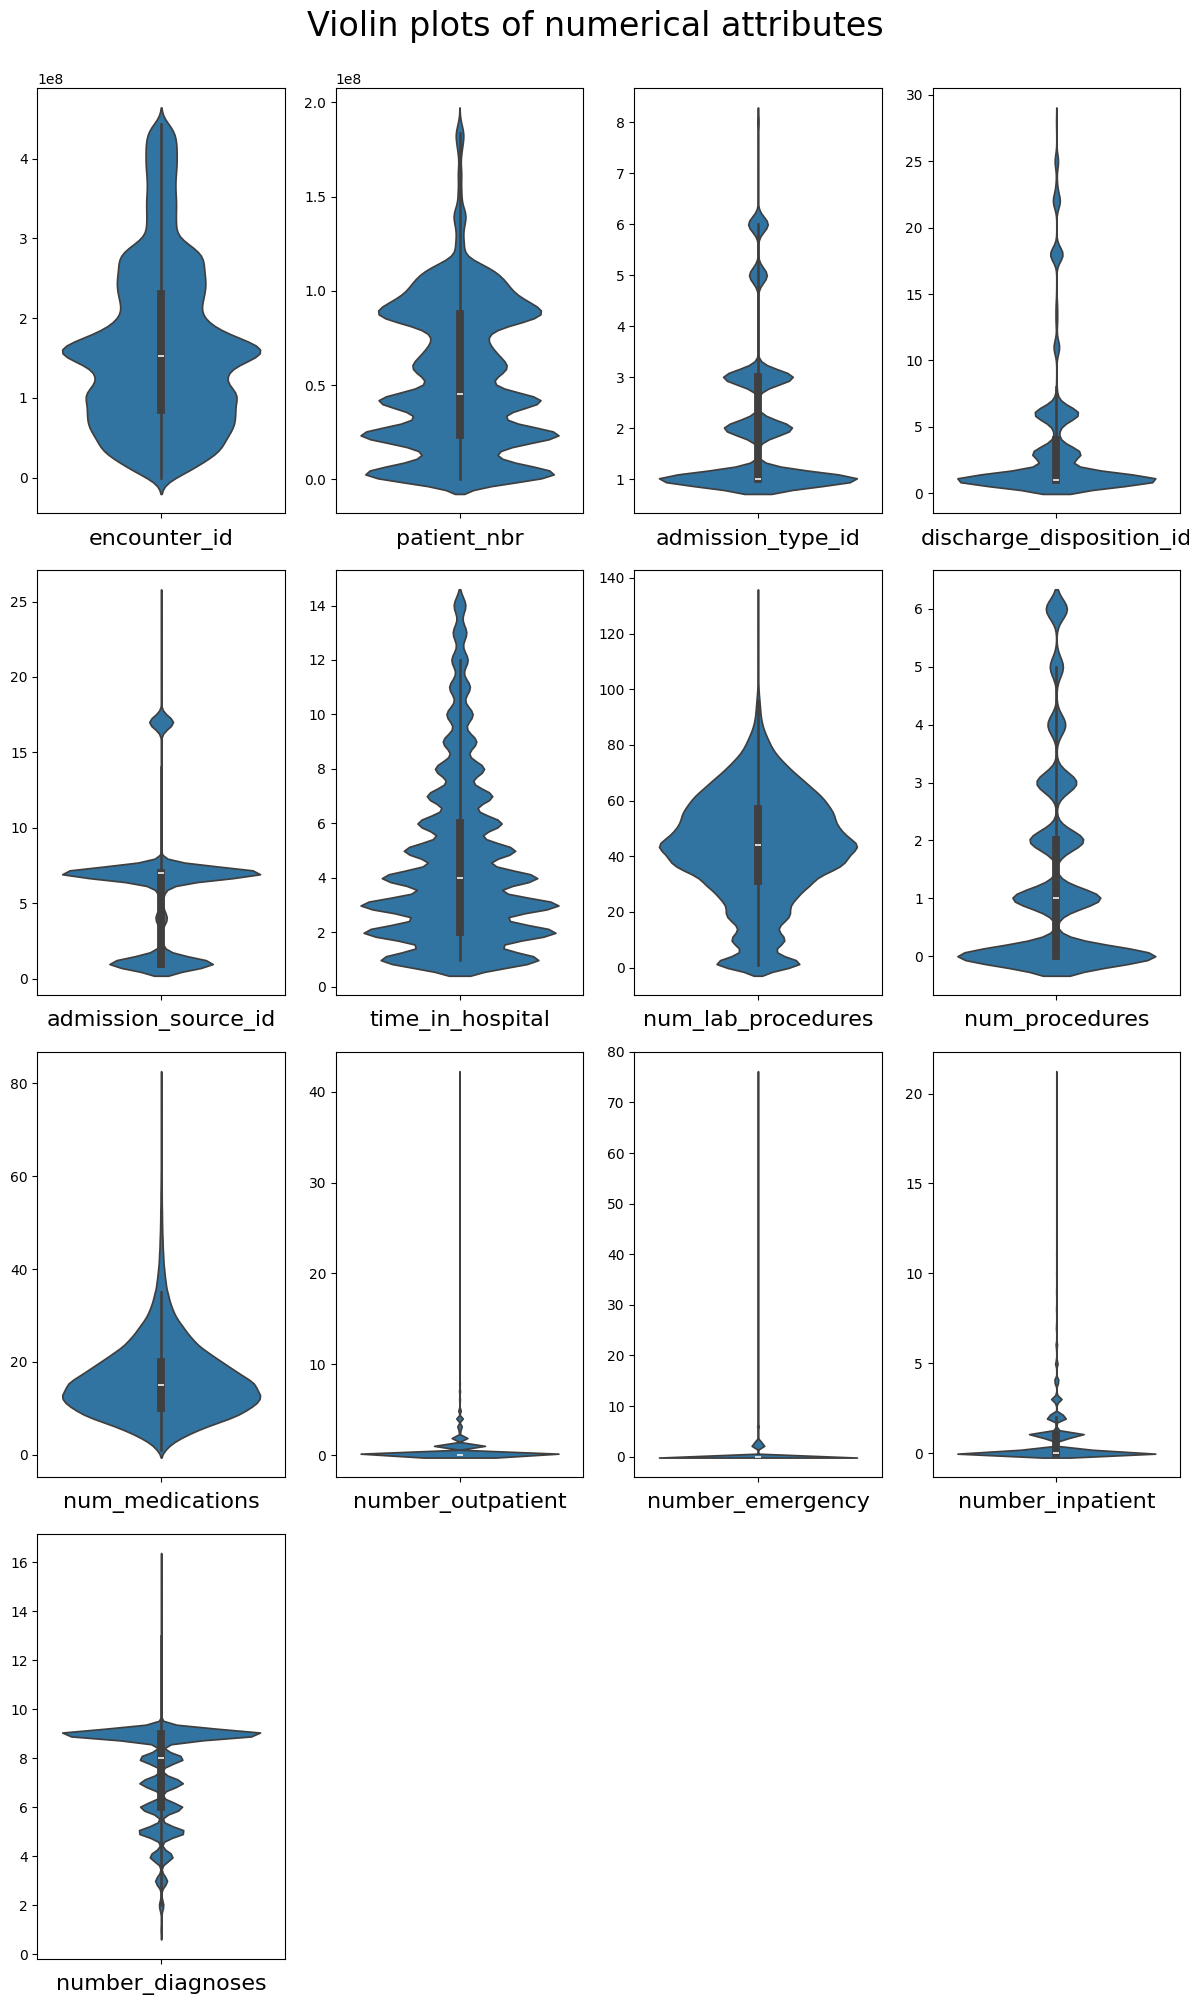

In [ ]:
plot_numerical_cols(df)